In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import learning_curve
from preprocessing import load_and_split, build_preprocessor

In [12]:
x_train, x_test, y_train, y_test = load_and_split("../data/student-mat.csv")
print("Train:", x_train.shape)
print("Test:", x_test.shape)

Train: (316, 11)
Test: (79, 11)


In [3]:
pipeline = Pipeline([
    ("preprocessing", build_preprocessor()),
    ("model", RandomForestRegressor(
        n_estimators=100, 
        max_depth=5, 
        random_state=42
    ))
])
pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)

In [11]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")
print(f"MAPE: {mape:.4f}")

MAE: 1.0848
RMSE: 1.6876
R2: 0.8611
MAPE: 1042906830799333.5000


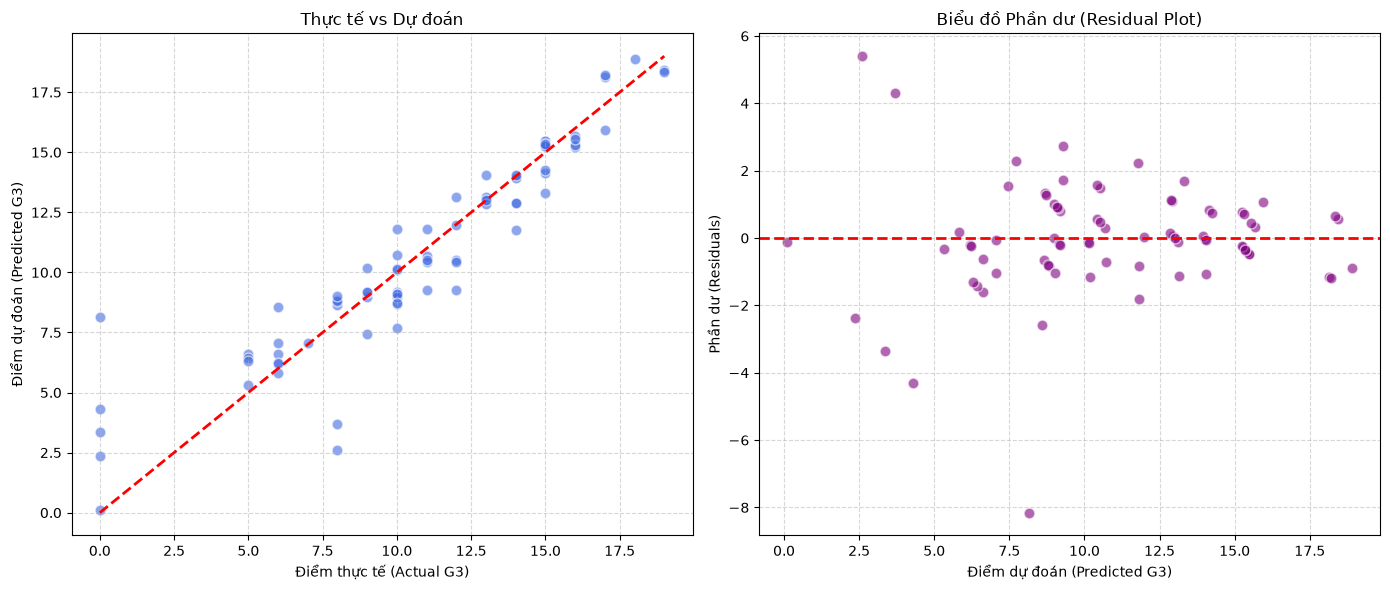

In [5]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.6, color='royalblue', edgecolors='w', s=60)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Điểm thực tế (Actual G3)')
plt.ylabel('Điểm dự đoán (Predicted G3)')
plt.title('Thực tế vs Dự đoán')
plt.grid(True, linestyle='--', alpha=0.5)

plt.subplot(1, 2, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.6, color='purple', edgecolors='w', s=60)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Điểm dự đoán (Predicted G3)')
plt.ylabel('Phần dư (Residuals)')
plt.title('Biểu đồ Phần dư (Residual Plot)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

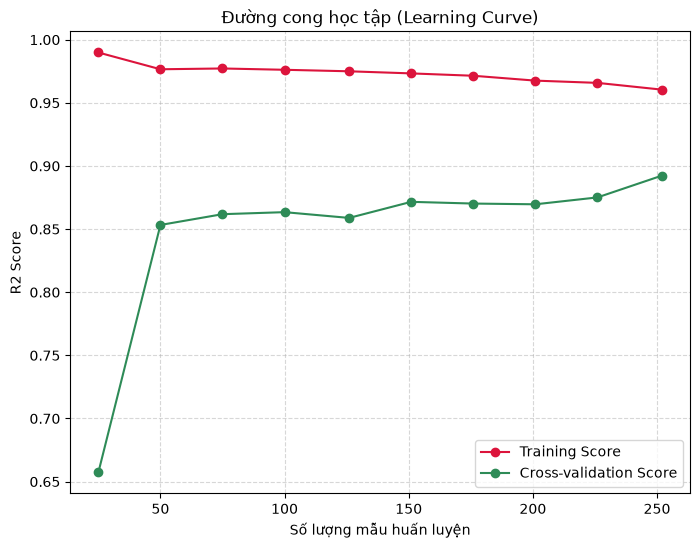

In [6]:
train_sizes, train_scores, test_scores = learning_curve(
    pipeline, x_train, y_train, cv=5, scoring='r2', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10) # 10 điểm dữ liệu trên đường cong
)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, np.mean(train_scores, axis=1), 'o-', color='crimson', label='Training Score')
plt.plot(train_sizes, np.mean(test_scores, axis=1), 'o-', color='seagreen', label='Cross-validation Score')
plt.xlabel('Số lượng mẫu huấn luyện')
plt.ylabel('R2 Score')
plt.title('Đường cong học tập (Learning Curve)')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

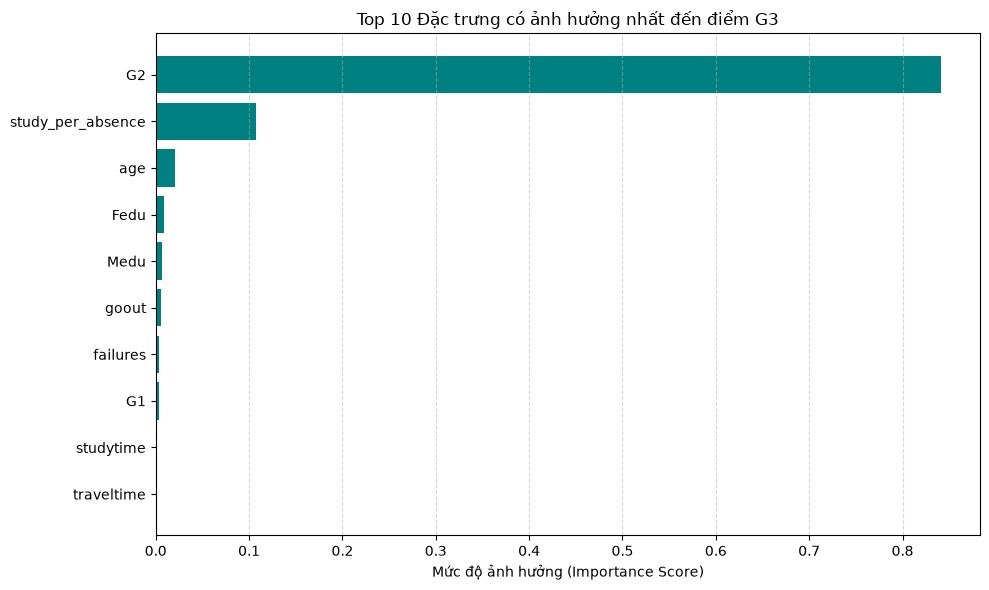

In [ ]:
feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()
importances = pipeline.named_steps['model'].feature_importances_

# Lấy Top 10 đặc trưng
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.title('Top 10 Đặc trưng có ảnh hưởng nhất đến điểm G3')
plt.barh(range(len(indices)), importances[indices], color='teal', align='center')

# Làm sạch tên cột (loại bỏ tiền tố 'num__' do ColumnTransformer tạo ra)
clean_names = [name.split('__')[-1] for name in [feature_names[i] for i in indices]]
plt.yticks(range(len(indices)), clean_names)

plt.xlabel('Mức độ ảnh hưởng')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
error_df = pd.DataFrame({
    'Thực tế (G3)': y_test,
    'Dự đoán (G3)': y_pred,
    'Sai số tuyệt đối': np.abs(residuals)
})

top_errors = error_df.sort_values(by='Sai số tuyệt đối', ascending=False).head(3)

print("=== PHÂN TÍCH LỖI: TOP 3 CA DỰ ĐOÁN SAI LỆCH NHẤT ===")
for index in top_errors.index:
    print(f"\n[-] Học sinh ID: {index}")
    print(f"    + Điểm thực tế: {error_df.loc[index, 'Thực tế (G3)']}")
    print(f"    + Điểm dự đoán: {error_df.loc[index, 'Dự đoán (G3)']:.2f}")
    
    # In ra một số thông tin nền tảng của học sinh đó để giải thích lý do sai
    features_to_check = ['G1', 'G2', 'failures', 'studytime']
    available_features = [f for f in features_to_check if f in x_test.columns]
    
    if available_features:
        print(f"    + Hồ sơ học sinh này:\n{x_test.loc[index, available_features].to_string()}")

=== PHÂN TÍCH LỖI: TOP 3 CA DỰ ĐOÁN SAI LỆCH NHẤT ===

[-] Học sinh ID: 140
    + Điểm thực tế: 0
    + Điểm dự đoán: 8.15
    + Hồ sơ học sinh này:
G1           7
G2           9
failures     0
studytime    4

[-] Học sinh ID: 124
    + Điểm thực tế: 8
    + Điểm dự đoán: 2.60
    + Hồ sơ học sinh này:
G1           8
G2           7
failures     0
studytime    2

[-] Học sinh ID: 90
    + Điểm thực tế: 8
    + Điểm dự đoán: 3.69
    + Hồ sơ học sinh này:
G1           7
G2           7
failures     0
studytime    3


## Đánh giá phân loại Pass/Fail (ngưỡng G3 = 10)

Chuyển bài toán hồi quy điểm G3 sang góc nhìn phân loại nhị phân (Pass nếu G3 ≥ 10, Fail nếu G3 < 10) để đánh giá thêm bằng ma trận nhầm lẫn và đường cong ROC.

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
import seaborn as sns

# Ngưỡng phân loại Pass/Fail
THRESHOLD = 10
y_test_binary = (y_test >= THRESHOLD).astype(int)
y_pred_binary = (y_pred >= THRESHOLD).astype(int)

In [ ]:
cm = confusion_matrix(y_test_binary, y_pred_binary)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', cbar=False,
    xticklabels=['Dự đoán: Fail (<10)', 'Dự đoán: Pass (≥10)'],
    yticklabels=['Thực tế: Fail (<10)', 'Thực tế: Pass (≥10)'],
    annot_kws={'size': 16}
)
plt.title('Ma trận nhầm lẫn — Random Forest\n(ngưỡng phân loại Pass/Fail tại G3 = 10)')
plt.tight_layout()
plt.show()

In [ ]:
# Huấn luyện thêm Gradient Boosting và Linear Regression để so sánh trên đường cong ROC
gb_pipeline = Pipeline([
    ("preprocessing", build_preprocessor()),
    ("model", GradientBoostingRegressor(random_state=42))
])
gb_pipeline.fit(x_train, y_train)
y_pred_gb = gb_pipeline.predict(x_test)

lr_pipeline = Pipeline([
    ("preprocessing", build_preprocessor()),
    ("model", LinearRegression())
])
lr_pipeline.fit(x_train, y_train)
y_pred_lr = lr_pipeline.predict(x_test)

In [ ]:
plt.figure(figsize=(7, 6))

model_scores = {
    'Random Forest': y_pred,
    'Gradient Boosting': y_pred_gb,
    'Linear Regression': y_pred_lr
}
colors = {
    'Random Forest': 'royalblue',
    'Gradient Boosting': 'green',
    'Linear Regression': 'crimson'
}

for name, scores in model_scores.items():
    fpr, tpr, _ = roc_curve(y_test_binary, scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})', color=colors[name])

plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.5000)')
plt.xlabel('Tỉ lệ dương tính giả (False Positive Rate)')
plt.ylabel('Tỉ lệ dương tính thật (True Positive Rate)')
plt.title('Đường cong ROC — phân loại Pass/Fail (G3 ≥ 10)\ndựa trên điểm dự đoán liên tục của 3 mô hình')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()